<a id="sec-top"></a>
# 🔁 Rossmann Store Sales — Rolling-Window Backtesting & Final Model Selection

**Project:** Rossmann Sales Forecasting
**Notebook:** `05_backtesting_evaluation.ipynb`
**Input:** `sales_daily` table (classical models), `features.parquet` (LSTM)
**Output:** a backtest results table across multiple time windows, and a
final, statistically-grounded `models/model_registry.json` recording which
model to serve per store

### 🎯 Purpose of this notebook
The single train/validation split used in `03_modeling_classical.ipynb` and
`04_modeling_lstm.ipynb` showed LSTM winning on 3 of 5 stores and SARIMA
winning on the other 2 — but that's based on **one** 6-week holdout period,
which could just be luck of which weeks got held out. This notebook repeats
the train → predict → evaluate cycle across **multiple, non-overlapping time
windows** (a proper backtest) to check whether that pattern holds up, before
locking in a per-store model choice for production.

### ⚠️ Compute cost warning
This notebook refits every model (SARIMA, Prophet, LSTM) **once per fold, per
store** — that's `n_folds × n_stores` model fits for the classical models,
plus `n_folds` LSTM retrains (pooled across stores). With the defaults below
(3 folds × 5 stores), expect this to take a while to run, especially the
LSTM section. Reduce `N_FOLDS` or `SAMPLE_STORE_IDS` first if you just want
to confirm the pipeline works before a full run.

---

## 📑 Table of Contents
- [0. Setup](#sec-0)
- [1. Define Rolling Windows](#sec-1)
- [2. Backtest: Seasonal-Naive](#sec-2)
- [3. Backtest: SARIMA](#sec-3)
- [4. Backtest: Prophet](#sec-4)
- [5. Backtest: LSTM](#sec-5)
- [6. Aggregate Results Across Folds](#sec-6)
- [7. Final Model Selection Per Store](#sec-7)
- [8. Update Model Registry](#sec-8)
- [9. Summary & Next Steps](#sec-9)

---

<a id="sec-0"></a>
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

import sys, os
sys.path.append(os.path.abspath(".."))

from src.evaluation.metrics import evaluate_forecast
from src.evaluation.backtest import generate_rolling_windows, summarize_backtest_results

In [2]:
from sqlalchemy import create_engine
engine = create_engine("sqlite:///../data/processed/rossmann.db")

def run_query(query: str) -> pd.DataFrame:
    return pd.read_sql(query, engine)

SAMPLE_STORE_IDS = [1, 2, 85, 262, 733]  # same sample used in notebooks 03 & 04
N_FOLDS = 3
HORIZON_DAYS = 14  # length of each validation window

In [3]:
def load_store_series(store_id: int) -> pd.DataFrame:
    query = f"""
    SELECT date, sales, promo, school_holiday, state_holiday, open
    FROM sales_daily
    WHERE store_id = {store_id}
    ORDER BY date;
    """
    df = run_query(query)
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").asfreq("D")
    df["sales"] = df["sales"].fillna(0)
    df["open"] = df["open"].fillna(0)
    for col in ["promo", "school_holiday"]:
        df[col] = df[col].fillna(0)
    df["state_holiday"] = df["state_holiday"].fillna("0")
    return df

---

<a id="sec-1"></a>
## 1. Define Rolling Windows

Uses `generate_rolling_windows()` from `src/evaluation/backtest.py` — an
expanding-window backtest: each fold trains on everything up to that fold's
cutoff and validates on the following `HORIZON_DAYS`, walking backward from
the most recent data.

In [4]:
max_date = load_store_series(SAMPLE_STORE_IDS[0]).index.max()
folds = generate_rolling_windows(max_date, n_folds=N_FOLDS, horizon_days=HORIZON_DAYS)

for f in folds:
    print(f"Fold {f.fold_id}: train up to {f.train_end.date()}  |  "
          f"validate {f.val_start.date()} -> {f.val_end.date()}")

Fold 3: train up to 2015-06-19  |  validate 2015-06-20 -> 2015-07-03
Fold 2: train up to 2015-07-03  |  validate 2015-07-04 -> 2015-07-17
Fold 1: train up to 2015-07-17  |  validate 2015-07-18 -> 2015-07-31


📝 **Note:** fold 1 (earliest) uses the least training data and the oldest
validation period; the last fold uses nearly the full history and validates
on the most recent weeks. This mirrors how the model would actually be
retrained and evaluated over time in production.

---

<a id="sec-2"></a>
## 2. Backtest: Seasonal-Naive

No training needed — just re-run the same "sales = 7 days ago" logic within
each fold's validation window.

In [5]:
def seasonal_naive_forecast(history: pd.Series, horizon: int, season_length: int = 7) -> np.ndarray:
    last_season = history.iloc[-season_length:].values
    reps = int(np.ceil(horizon / season_length))
    return np.tile(last_season, reps)[:horizon]

In [6]:
naive_results = []

for store_id in SAMPLE_STORE_IDS:
    series = load_store_series(store_id)
    for fold in folds:
        train = series[series.index <= fold.train_end]
        val = series[(series.index >= fold.val_start) & (series.index <= fold.val_end)]
        if len(val) == 0 or len(train) < 7:
            continue
        pred = seasonal_naive_forecast(train["sales"], horizon=len(val))
        metrics = evaluate_forecast(val["sales"].values, pred)
        naive_results.append({"store_id": store_id, "fold_id": fold.fold_id,
                                "model": "naive", **metrics})

naive_results_df = pd.DataFrame(naive_results)
naive_results_df.head(10)

,store_id,fold_id,model,MAE,RMSE,MAPE
0,1,3,naive,686.571429,842.573269,19.272286
1,1,2,naive,767.428571,979.922883,22.053700
2,1,1,naive,647.000000,809.039024,18.285128
3,2,3,naive,1168.071429,1729.493382,27.710608
4,2,2,naive,1524.214286,2261.363448,38.313084
5,2,1,naive,808.142857,1125.480532,21.279445
6,85,3,naive,1065.285714,1274.941007,15.225602
7,85,2,naive,1190.357143,1513.926093,17.203215
8,85,1,naive,1069.785714,1445.427594,17.115136
9,262,3,naive,2179.714286,2445.880765,11.739857


---

<a id="sec-3"></a>
## 3. Backtest: SARIMA

Refits a fresh SARIMA model for each (store, fold) combination — this is the
expensive part for this model family. Same order/exogenous setup as
`03_modeling_classical.ipynb`.

In [7]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

exog_cols = ["promo", "school_holiday"]
sarima_results = []

for store_id in SAMPLE_STORE_IDS:
    series = load_store_series(store_id)
    for fold in folds:
        train = series[series.index <= fold.train_end]
        val = series[(series.index >= fold.val_start) & (series.index <= fold.val_end)]
        if len(val) == 0 or len(train) < 60:
            continue
        try:
            model = SARIMAX(train["sales"], exog=train[exog_cols],
                             order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                             enforce_stationarity=False, enforce_invertibility=False)
            fit = model.fit(disp=False)
            pred = fit.forecast(steps=len(val), exog=val[exog_cols])
            metrics = evaluate_forecast(val["sales"].values, pred.values)
            sarima_results.append({"store_id": store_id, "fold_id": fold.fold_id,
                                     "model": "sarima", **metrics})
        except Exception as e:
            print(f"  [store {store_id}, fold {fold.fold_id}] SARIMA failed: {e}")

sarima_results_df = pd.DataFrame(sarima_results)
sarima_results_df.head(10)

,store_id,fold_id,model,MAE,RMSE,MAPE
0,1,3,sarima,374.146755,511.179186,8.240496
1,1,2,sarima,272.664284,409.837630,7.575519
2,1,1,sarima,272.972075,317.487050,6.426772
3,2,3,sarima,652.584819,1072.503870,13.234557
4,2,2,sarima,803.040678,948.807888,18.900472
5,2,1,sarima,539.951628,704.204812,13.411082
6,85,3,sarima,502.573686,646.104700,7.872714
7,85,2,sarima,508.868915,656.227342,6.815719
8,85,1,sarima,493.365450,643.295078,6.923685
9,262,3,sarima,1227.141710,1617.970538,6.670102


---

<a id="sec-4"></a>
## 4. Backtest: Prophet

Same regressor setup as `03_modeling_classical.ipynb`, refit per fold.

In [8]:
!python -m pip uninstall protobuf -y
!python -m pip install protobuf==6.31.1

Found existing installation: protobuf 6.31.1
Uninstalling protobuf-6.31.1:
  Successfully uninstalled protobuf-6.31.1
  Using cached protobuf-6.31.1-cp310-abi3-win_amd64.whl.metadata (593 bytes)
Using cached protobuf-6.31.1-cp310-abi3-win_amd64.whl (435 kB)



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import google.protobuf

print(google.protobuf.__version__)

import tensorflow as tf
print(tf.__version__)

6.31.1
2.21.0


In [10]:
from prophet import Prophet

prophet_results = []

for store_id in SAMPLE_STORE_IDS:
    series = load_store_series(store_id)
    for fold in folds:
        train = series[series.index <= fold.train_end].reset_index().rename(columns={"date": "ds", "sales": "y"})
        val = series[(series.index >= fold.val_start) & (series.index <= fold.val_end)].reset_index().rename(columns={"date": "ds", "sales": "y"})
        if len(val) == 0 or len(train) < 60:
            continue
        try:
            pm = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
            pm.add_regressor("promo")
            pm.add_regressor("school_holiday")
            pm.fit(train[["ds", "y", "promo", "school_holiday"]])
            forecast = pm.predict(val[["ds", "promo", "school_holiday"]])
            metrics = evaluate_forecast(val["y"].values, forecast["yhat"].values)
            prophet_results.append({"store_id": store_id, "fold_id": fold.fold_id,
                                      "model": "prophet", **metrics})
        except Exception as e:
            print(f"  [store {store_id}, fold {fold.fold_id}] Prophet failed: {e}")

prophet_results_df = pd.DataFrame(prophet_results)
prophet_results_df.head(10)

23:38:09 - cmdstanpy - INFO - Chain [1] start processing
23:38:10 - cmdstanpy - INFO - Chain [1] done processing
23:38:10 - cmdstanpy - INFO - Chain [1] start processing
23:38:11 - cmdstanpy - INFO - Chain [1] done processing
23:38:11 - cmdstanpy - INFO - Chain [1] start processing
23:38:11 - cmdstanpy - INFO - Chain [1] done processing
23:38:12 - cmdstanpy - INFO - Chain [1] start processing
23:38:12 - cmdstanpy - INFO - Chain [1] done processing
23:38:12 - cmdstanpy - INFO - Chain [1] start processing
23:38:12 - cmdstanpy - INFO - Chain [1] done processing
23:38:13 - cmdstanpy - INFO - Chain [1] start processing
23:38:13 - cmdstanpy - INFO - Chain [1] done processing
23:38:13 - cmdstanpy - INFO - Chain [1] start processing
23:38:14 - cmdstanpy - INFO - Chain [1] done processing
23:38:14 - cmdstanpy - INFO - Chain [1] start processing
23:38:14 - cmdstanpy - INFO - Chain [1] done processing
23:38:14 - cmdstanpy - INFO - Chain [1] start processing
23:38:15 - cmdstanpy - INFO - Chain [1]

,store_id,fold_id,model,MAE,RMSE,MAPE
0,1,3,prophet,381.938320,482.343633,8.548982
1,1,2,prophet,323.898059,450.127491,8.688283
2,1,1,prophet,304.885296,390.072433,7.372252
3,2,3,prophet,613.988637,1003.356639,12.259912
4,2,2,prophet,569.576755,661.599638,13.436316
5,2,1,prophet,359.257611,432.306282,9.151728
6,85,3,prophet,544.266272,709.103975,8.510648
7,85,2,prophet,555.892425,697.248478,7.213952
8,85,1,prophet,465.669519,658.493644,6.077833
9,262,3,prophet,1440.963764,1611.348939,7.341376


---

<a id="sec-5"></a>
## 5. Backtest: LSTM

The LSTM is pooled across stores (as in `04_modeling_lstm.ipynb`), so it's
retrained **once per fold** (not once per store per fold) — still 3 full
retrains with the defaults, which is the slowest part of this notebook.
Epochs are reduced vs. Notebook 04 to keep total runtime reasonable; increase
`EPOCHS` if you have time and want closer-to-final numbers.

In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler

tf.random.set_seed(42)
np.random.seed(42)

LOOKBACK = 14
EPOCHS = 30  # reduced from Notebook 04's 100 for backtest runtime; raise if feasible

FEATURE_COLS = [
    "day_of_week_sin", "day_of_week_cos", "month_sin", "month_cos",
    "is_weekend", "promo", "school_holiday", "is_promo2_active", "promo_start_flag",
    "competition_distance", "months_since_competition_open",
    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_28",
    "sales_rolling_mean_7", "sales_rolling_mean_30",
    "sales_rolling_std_7", "sales_rolling_min_7", "sales_rolling_max_7",
]

df_features = pd.read_parquet("../data/processed/features.parquet")
df_features["date"] = pd.to_datetime(df_features["date"])
FEATURE_COLS += [c for c in df_features.columns if c.startswith("store_type_") or c.startswith("assortment_")]

df_lstm = df_features[df_features["store_id"].isin(SAMPLE_STORE_IDS)].copy()
df_lstm = df_lstm.sort_values(["store_id", "date"]).reset_index(drop=True)

In [12]:
def create_sequences(store_df, feature_cols, target_col, lookback):
    values = store_df[feature_cols].values
    target = store_df[target_col].values
    dates = store_df["date"].values
    X, y, target_dates = [], [], []
    for i in range(lookback, len(store_df)):
        X.append(values[i - lookback:i])
        y.append(target[i])
        target_dates.append(dates[i])
    return np.array(X), np.array(y), np.array(target_dates)


def build_lstm(n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(LOOKBACK, n_features)),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1),
    ])
    model.compile(optimizer="adam", loss="mse")
    return model

In [13]:
lstm_results = []

for fold in folds:
    train_df = df_lstm[df_lstm["date"] <= fold.train_end].copy()
    val_df = df_lstm[(df_lstm["date"] >= fold.val_start) & (df_lstm["date"] <= fold.val_end)].copy()
    if train_df.empty or val_df.empty:
        continue

    # Scale using ONLY this fold's training data -- avoids leaking later folds'
    # value ranges into an earlier fold's model.
    feature_scaler = MinMaxScaler().fit(train_df[FEATURE_COLS])
    target_scaler = MinMaxScaler().fit(train_df[["sales"]])

    fold_df = df_lstm[df_lstm["date"] <= fold.val_end].copy()
    fold_df[FEATURE_COLS] = feature_scaler.transform(fold_df[FEATURE_COLS])
    fold_df["sales_scaled"] = target_scaler.transform(fold_df[["sales"]])

    all_X, all_y, all_dates, all_stores = [], [], [], []
    for store_id, sdf in fold_df.groupby("store_id"):
        sdf = sdf.sort_values("date").reset_index(drop=True)
        X, y, dates = create_sequences(sdf, FEATURE_COLS, "sales_scaled", LOOKBACK)
        all_X.append(X); all_y.append(y); all_dates.append(dates)
        all_stores.extend([store_id] * len(y))

    X_all = np.concatenate(all_X); y_all = np.concatenate(all_y)
    dates_all = np.concatenate(all_dates); stores_all = np.array(all_stores)

    train_mask = dates_all <= np.datetime64(fold.train_end)
    val_mask = (dates_all >= np.datetime64(fold.val_start)) & (dates_all <= np.datetime64(fold.val_end))

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_val, y_val = X_all[val_mask], y_all[val_mask]
    stores_val = stores_all[val_mask]

    if len(X_train) < 50 or len(X_val) == 0:
        print(f"  Fold {fold.fold_id}: not enough data, skipping")
        continue

    model = build_lstm(len(FEATURE_COLS))
    early_stop = EarlyStopping(monitor="loss", patience=5, restore_best_weights=True)
    model.fit(X_train, y_train, epochs=EPOCHS, batch_size=32, callbacks=[early_stop], verbose=0)

    y_pred_scaled = model.predict(X_val, verbose=0).flatten()
    y_val_actual = target_scaler.inverse_transform(y_val.reshape(-1, 1)).flatten()
    y_pred_actual = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

    fold_result_df = pd.DataFrame({"store_id": stores_val, "actual": y_val_actual, "predicted": y_pred_actual})
    for store_id, g in fold_result_df.groupby("store_id"):
        metrics = evaluate_forecast(g["actual"].values, g["predicted"].values)
        lstm_results.append({"store_id": store_id, "fold_id": fold.fold_id, "model": "lstm", **metrics})

    print(f"Fold {fold.fold_id} done.")

lstm_results_df = pd.DataFrame(lstm_results)
lstm_results_df.head(10)

Fold 3 done.
Fold 2 done.
Fold 1 done.


,store_id,fold_id,model,MAE,RMSE,MAPE
0,1,3,lstm,493.626811,596.279133,12.584586
1,2,3,lstm,715.869141,1060.957428,13.839653
2,85,3,lstm,652.635010,825.700562,8.835090
3,262,3,lstm,1637.791574,1857.992772,8.134049
4,733,3,lstm,905.034947,1148.693788,5.672401
5,1,2,lstm,265.033366,352.299790,6.646342
6,2,2,lstm,571.889181,718.159947,12.349536
7,85,2,lstm,730.428502,966.985023,8.925561
8,262,2,lstm,1247.308873,1523.874600,5.686155
9,733,2,lstm,1240.522391,1384.308421,8.830313


---

<a id="sec-6"></a>
## 6. Aggregate Results Across Folds

Combine all four models' per-fold results, then compute mean/std MAPE per
store per model — the standard deviation across folds is just as important
as the mean here: a model with a low average MAPE but high fold-to-fold
variance is less trustworthy than one that's consistently decent.

In [14]:
all_results = pd.concat([naive_results_df, sarima_results_df, prophet_results_df, lstm_results_df],
                          ignore_index=True)
all_results.head(10)

,store_id,fold_id,model,MAE,RMSE,MAPE
0,1,3,naive,686.571429,842.573269,19.272286
1,1,2,naive,767.428571,979.922883,22.053700
2,1,1,naive,647.000000,809.039024,18.285128
3,2,3,naive,1168.071429,1729.493382,27.710608
4,2,2,naive,1524.214286,2261.363448,38.313084
5,2,1,naive,808.142857,1125.480532,21.279445
6,85,3,naive,1065.285714,1274.941007,15.225602
7,85,2,naive,1190.357143,1513.926093,17.203215
8,85,1,naive,1069.785714,1445.427594,17.115136
9,262,3,naive,2179.714286,2445.880765,11.739857


In [15]:
summary = summarize_backtest_results(all_results, group_cols=["store_id", "model"], metric_col="MAPE")
summary_pivot = summary.pivot(index="store_id", columns="model", values="MAPE_mean")
summary_pivot

model,lstm,naive,prophet,sarima
store_id,,,,
1,9.672636,19.870371,8.203172,7.414262
2,12.472658,29.101045,11.615985,15.182037
85,8.023519,16.514651,7.267477,7.204039
262,8.236542,9.450938,7.735513,5.720327
733,6.863033,11.171381,6.280200,7.927267


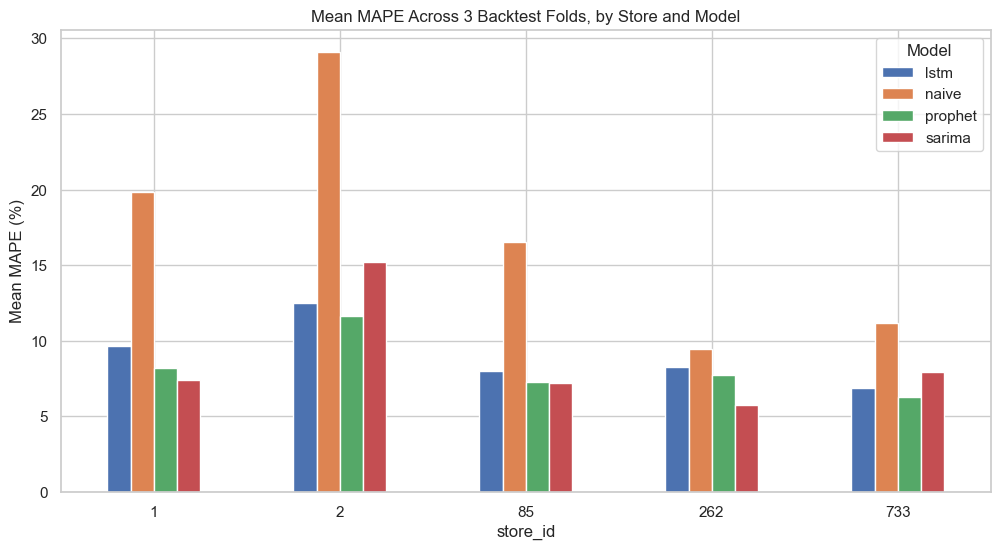

In [16]:
fig, ax = plt.subplots(figsize=(12, 6))
summary_pivot.plot(kind="bar", ax=ax)
ax.set_title(f"Mean MAPE Across {N_FOLDS} Backtest Folds, by Store and Model")
ax.set_ylabel("Mean MAPE (%)")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

In [17]:
# Variability check -- a model that looks good on average but swings wildly
# across folds is a riskier choice to deploy than a consistently mediocre one.
std_pivot = summary.pivot(index="store_id", columns="model", values="MAPE_std")
std_pivot

model,lstm,naive,prophet,sarima
store_id,,,,
1,2.970773,1.954178,0.722961,0.917552
2,1.309782,8.601523,2.213686,3.221468
85,1.484722,1.117218,1.217290,0.581600
262,2.603146,2.266102,1.558522,0.957912
733,1.716243,4.590710,1.890370,1.949577


📝 **Insight:** compare this table against the single-split results from
Notebooks 03/04. Did the "winning" model per store stay the same, or did the
extra folds reveal a different, more reliable pattern? Also flag any
model/store combination with unusually high `MAPE_std` — that's a sign the
single-split result you saw earlier may have been a lucky (or unlucky) fold.

---

<a id="sec-7"></a>
## 7. Final Model Selection Per Store

Pick the model with the lowest **mean** MAPE across folds for each store —
this is now a decision backed by multiple time windows, not a single
train/val split.

In [18]:
best_model_per_store = summary_pivot.idxmin(axis=1)
best_mape_per_store = summary_pivot.min(axis=1)

final_selection = pd.DataFrame({
    "selected_model": best_model_per_store,
    "backtest_mean_mape": best_mape_per_store,
})
final_selection

,selected_model,backtest_mean_mape
store_id,,
1,sarima,7.414262
2,prophet,11.615985
85,sarima,7.204039
262,sarima,5.720327
733,prophet,6.280200


📝 **Insight:** if a store's SARIMA and LSTM scores are within a fraction of a
percentage point of each other (a near-tie), consider preferring the
**simpler, cheaper-to-serve model** (SARIMA/Prophet don't need scalers, model
files, or GPU-friendly serving — LSTM does) rather than always defaulting to
whichever number is marginally lower.

---

<a id="sec-8"></a>
## 8. Update Model Registry

Write the backtest-informed decision into `models/model_registry.json` — this
is what the FastAPI `/forecast` endpoint will read to pick which model to
load for a given `store_id`.

In [19]:
import json

registry_path = "../models/model_registry.json"
registry = {}
if os.path.exists(registry_path) and os.path.getsize(registry_path) > 0:
    with open(registry_path) as f:
        registry = json.load(f)

for store_id, row in final_selection.iterrows():
    key = str(store_id)
    if key not in registry:
        registry[key] = {}
    registry[key]["selected_model"] = row["selected_model"]
    registry[key]["backtest_mean_mape"] = float(row["backtest_mean_mape"])
    registry[key]["backtest_n_folds"] = N_FOLDS
    registry[key]["backtest_horizon_days"] = HORIZON_DAYS

with open(registry_path, "w") as f:
    json.dump(registry, f, indent=2)

print(f"Updated {registry_path} with backtest-informed model selection for {len(final_selection)} stores")

Updated ../models/model_registry.json with backtest-informed model selection for 5 stores


---

<a id="sec-9"></a>
## 9. Summary & Next Steps

*(Fill in after running the full backtest.)*

### Results
- **Final model selection per store:** [paste Section 7's table]
- **Did the winner change vs. the single-split result in Notebooks 03/04?** [note any flips]
- **Most/least stable model (by MAPE_std):** [note from Section 6]

### Business framing
- Average MAPE improvement of the selected models over the seasonal-naive
  baseline: [compute and fill in — this is your strongest README number]
- [Optional] Translate the MAPE improvement into an inventory-cost estimate,
  e.g. "at an average X% forecast error reduction, a simple newsvendor-style
  safety-stock calculation suggests ~$Y/month in reduced over/understock
  costs across the sampled stores" — a concrete business number is far more
  compelling to a hiring manager than a MAPE table alone.

### Next steps — deployment
With a backtest-validated `model_registry.json` in place, the project is
ready for the deployment phase:
- `api/` — FastAPI service that reads `model_registry.json`, loads the
  selected model per store, and serves `/forecast?store_id=X&horizon=14`
- `frontend/` — Streamlit dashboard calling that API
- `docker/` — containerize both, deploy via Render/Railway + Streamlit Cloud

---
[⬆ Back to top](#sec-top)